In [403]:
import os
import platform
import subprocess
import re

import numpy as np
from scipy.stats import norm
import arviz as az
import pymc as pm
import pytensor.tensor as at
from dataclasses import dataclass
from typing import List, Tuple, Dict, Union


import matplotlib.pyplot as plt

In [404]:
az.style.use("arviz-doc")

## Helper Functions

### System utils

In [405]:
def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

### Data Processing

In [406]:
@dataclass
class CensoredData:
    y: List[float]
    lower_limits: List[float]
    upper_limits: List[float]
    uncensored_data: List[float]
    censored_data: List[float]
    censored_limits: List[float]

def define_observed_lower_upper(expo_data: List[str], oel:float) -> CensoredData:
    y = []
    lower_limits = []
    upper_limits = []

    for value in expo_data:
        if value.startswith('<'):
            # Left-censored
            limit = float(value[1:])  # Extract the numeric value
            y.append(limit)
            lower_limits.append(limit)
            upper_limits.append(np.inf)
        elif value.startswith('>'):
            # Right-censored
            limit = float(value[1:])  # Extract the numeric value
            y.append(limit)
            lower_limits.append(-np.inf)
            upper_limits.append(limit)
        elif '-' in value:
            # Interval-censored
            lower, upper = map(float, value.split('-'))  # Extract the range
            y.append((lower + upper) / 2)
            lower_limits.append(lower)
            upper_limits.append(upper)
        else:
            # Uncensored
            y.append(float(value))
            lower_limits.append(-np.inf)
            upper_limits.append(np.inf)
        
    # Divide all values by the OEL, excluding infinite values
    y = [value / oel if value != np.inf and value != -np.inf else value for value in y]
    lower_limits = [value / oel if value != np.inf and value != -np.inf else value for value in lower_limits]
    upper_limits = [value / oel if value != np.inf and value != -np.inf else value for value in upper_limits]
    
    # Separate the data into two additional lists for censored and uncensored data, using the lower and upper limits as index for y
    uncensored_data = [value for value in y if value in lower_limits or value in upper_limits]
    censored_limits = [value for value in lower_limits if value in uncensored_data] + [value for value in upper_limits if value in uncensored_data]
    censored_data = [value for value in y if value not in uncensored_data]
    
    return CensoredData(y, lower_limits, upper_limits, censored_data, uncensored_data, censored_limits)

### Mu and sigma chain calculations

In [407]:
# Helper function for calculating statistics
def calculate_stats(
    chain: np.ndarray, 
    probacred: float, 
    precision: int = 3) -> Dict[str, float]:
    lower = (100 - probacred) / 200
    upper = 1 - lower
    return {
        "est": round(np.median(chain), precision),
        "lcl": round(np.quantile(chain, lower), precision),
        "ucl": round(np.quantile(chain, upper), precision),
    }

# Geometric mean
def geometric_mean(
    mu_chain: np.ndarray, 
    probacred: float, 
    precision: int = 3) -> Dict[str, float]:
    return calculate_stats(np.exp(mu_chain), probacred, precision)

# Geometric standard deviation
def geometric_sd(
    sigma_chain: np.ndarray, 
    probacred: float, 
    precision: int = 3) -> Dict[str, float]:
    return calculate_stats(np.exp(sigma_chain), probacred, precision)

# Exceedance fraction
def exceedance_fraction(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, precision: int = 3) -> Dict[str, float]:
    chain = 100 * (1 - norm.cdf((np.log(oel) - mu_chain) / sigma_chain))
    return calculate_stats(chain, probacred, precision)

# Percentile of interest
def percentile_of_interest(mu_chain: np.ndarray, sigma_chain: np.ndarray, target_perc: float, probacred: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + norm.ppf(target_perc / 100) * sigma_chain)
    return calculate_stats(chain, probacred, precision)

# Arithmetic mean
def arithmetic_mean(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    return calculate_stats(chain, probacred, precision)

# Fractional risk
def frac_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, frac_threshold: float, oel: float, precision: int = 3) -> float:
    chain = 100 * (1 - norm.cdf((np.log(oel) - mu_chain) / sigma_chain))
    return round(100 * np.sum(chain > frac_threshold) / len(chain), precision)

# Percentile risk
def perc_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, target_perc: float, oel: float, precision: int = 3) -> float:
    chain = np.exp(mu_chain + norm.ppf(target_perc / 100) * sigma_chain)
    return round(100 * np.sum(chain > oel) / len(chain), precision)

# Arithmetic mean risk
def am_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, oel: float, precision: int = 3) -> float:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    return round(100 * np.sum(chain > oel) / len(chain), precision)

# Risk bands for arithmetic mean
def am_riskbands(mu_chain: np.ndarray, sigma_chain: np.ndarray, oel: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    riskbands = 100 * np.histogram(chain, bins=[np.exp(-20), 0.01 * oel, 0.1 * oel, 0.5 * oel, oel, np.exp(20) * oel])[0] / len(chain)
    categories = ["<0.01*OEL", "[0.01-0.1]*OEL", "[0.1-0.5]*OEL", "[0.5-1]*OEL", ">OEL"]
    return {category: round(risk, precision) for category, risk in zip(categories, riskbands)}

# Aggregate all numeric results
def all_numeric(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, frac_threshold: float, target_perc: float, precision: int = 3) -> Dict[str, Union[Dict[str, float], float]]:
    return {
        "gm": geometric_mean(mu_chain, probacred, precision),
        "gsd": geometric_sd(sigma_chain, probacred, precision),
        "frac": exceedance_fraction(mu_chain, sigma_chain, probacred, oel, precision),
        "perc": percentile_of_interest(mu_chain, sigma_chain, target_perc, probacred, precision),
        "am": arithmetic_mean(mu_chain, sigma_chain, probacred, precision),
        "frac.risk": frac_risk(mu_chain, sigma_chain, frac_threshold, oel, precision),
        "perc.risk": perc_risk(mu_chain, sigma_chain, target_perc, oel, precision),
        "am.risk": am_risk(mu_chain, sigma_chain, oel, precision),
        "am.riskbands": am_riskbands(mu_chain, sigma_chain, oel, precision),
    }

# Interpretation function
def interpretation(is_lognormal: bool, mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, frac_threshold: float, target_perc: float, precision: int = 3) -> Dict[str, Union[Dict[str, float], float]]:
    if is_lognormal:
        return all_numeric(mu_chain, sigma_chain, probacred, oel, frac_threshold, target_perc, precision)
    else:
        raise NotImplementedError("Normal model interpretation is not implemented yet.")

# Past Data

Webexpo documnation for past data is lacking. 

Currently the last_data model chunk is 

```R
if (length(past.data)==3) past.data.chunk <- paste("mean.past ~ dnorm(mu, mean.past.precision)
                                                    mean.past.precision <- n.past / pow(sigma, 2)
                                                    ns2 ~ dgamma(ns2.a, b)
                                                    b <- pow(sigma, -2) / 2",sep='')
```

with the following variables (note how sd.past is commented out)

```R
if (length(past.data)==3) {
  
  dataList$mean.past <- past.data$mean
  #dataList$sd.past <- past.data$sd
  dataList$n.past <- past.data$n
  dataList$ns2 <- (dataList$n.past - 1) * (dataList$sd.past^2)
  dataList$ns2.a <- (dataList$n.past - 1) / 2
}
```



In [408]:
data = [24.7, 64.1, 13.8, 43.7, 19.9, 133, 32.1, 15, 53.7]
data = np.array(data_check) / 100

data_lower = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
data_upper = [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]

In [409]:
mean_past = 28
sd_past = 0.5
n_past = 10
ns2 = (n_past - 1) * (sd_past ** 2)
ns2_a = (n_past - 1) / 2

In [415]:
# Bayesian model with pm.Censored
with pm.Model() as past_data_model:
    # Priors
    mu = pm.Uniform("mu", lower=-20, upper=20)
    log_sigma = pm.Normal("log_sigma", mu=-0.1744, sigma= 2.5523)
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma))
    

    # Likelihood with censoring
    censored_observations = pm.Censored(
        "y",
        pm.Lognormal.dist(mu=mu, sigma=sigma),
        lower= data_lower,
        upper= data_upper,
        observed=data
    )
    
    mean_past_prec = pm.Deterministic("mean_past_prec", n_past / sigma**2)
    mean_past = pm.Normal("mean_past", mu=mu, tau = mean_past_prec)
    
    ns2_b = pm.Deterministic("ns2_b", sigma**-2 / mean_past_prec)
    ns2 = pm.Gamma("ns2", alpha=ns2_a, beta=ns2_b)

    # Sampling
    past_data_trace = pm.sample(
        draws=25000, 
        tune=5000, 
        chains=4, 
        return_inferencedata=True, 
        target_accept=0.90, 
        initvals={
            "mu": np.log(0.3), 
            "log_sigma": np.log(2.5)
            },
        nuts_sampler='blackjax'
        )

Running window adaptation


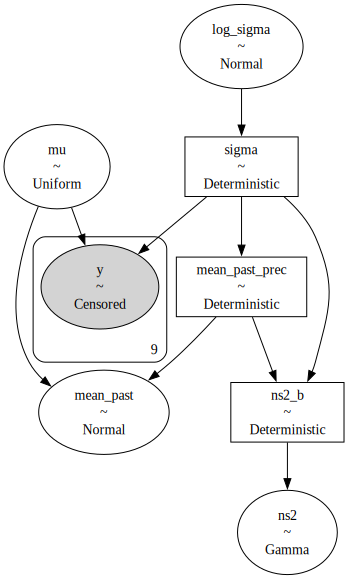

In [411]:
pm.model_to_graphviz(past_data_model)

<Axes: >

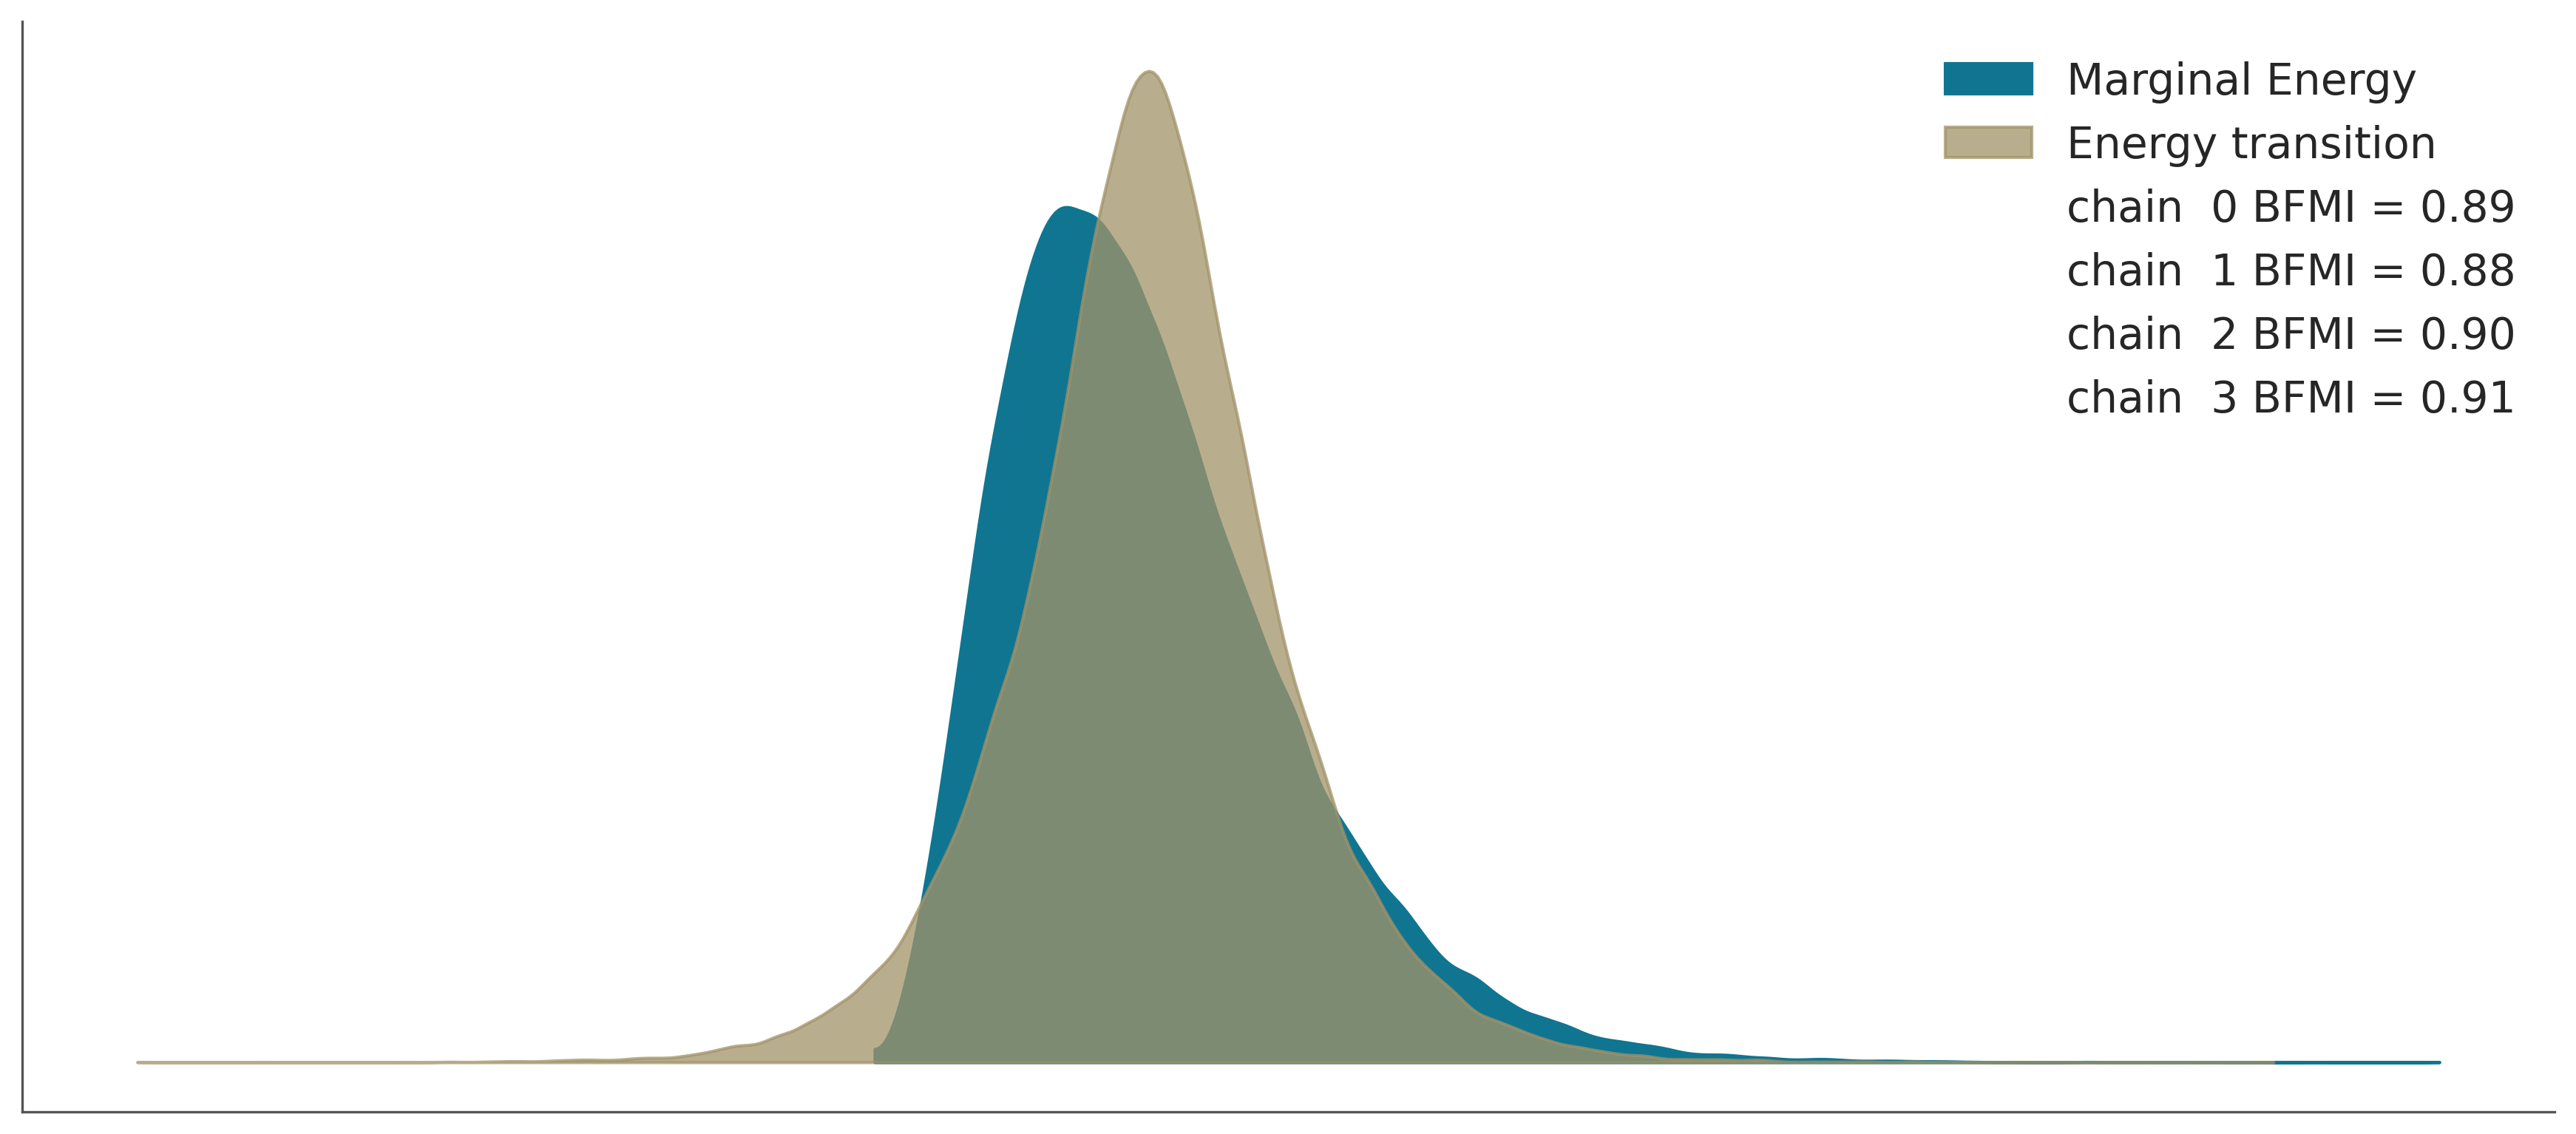

In [425]:
az.plot_energy(past_data_trace)

In [422]:
past_data_trace.posterior['mu'] = past_data_trace.posterior['mu'] + np.log(100)

In [423]:
# calculate posterior sample for 95th percentile

mu_chain = past_data_trace.posterior["mu"].values.flatten()
sigma_chain = past_data_trace.posterior["sigma"].values.flatten()

interpretation(
    is_lognormal=True,
    mu_chain=mu_chain,
    sigma_chain=sigma_chain,
    probacred=90,
    oel=100,
    frac_threshold=10,
    target_perc=95
)

{'gm': {'est': 34.285, 'lcl': 21.515, 'ucl': 54.334},
 'gsd': {'est': 2.173, 'lcl': 1.708, 'ucl': 3.567},
 'frac': {'est': 8.255, 'lcl': 1.391, 'ucl': 26.972},
 'perc': {'est': 122.084, 'lcl': 71.859, 'ucl': 323.692},
 'am': {'est': 46.764, 'lcl': 30.525, 'ucl': 95.771},
 'frac.risk': 41.283,
 'perc.risk': 70.12,
 'am.risk': 4.412,
 'am.riskbands': {'<0.01*OEL': 0.0,
  '[0.01-0.1]*OEL': 0.0,
  '[0.1-0.5]*OEL': 58.486,
  '[0.5-1]*OEL': 37.102,
  '>OEL': 4.412}}